In [2]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
import seaborn.objects as so

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
np.set_printoptions(suppress = True)
np.set_printoptions(precision = 2)

In [4]:
raw = "C:\\Users\\taavi\\Desktop\\BPHIL\\Raw data\\"
clean = "C:\\Users\\taavi\\Desktop\\BPHIL\\Clean data\\"
images = 'C:\\Users\\taavi\\Desktop\\BPHIL\\Images in defense ppt\\'

In [6]:
parcels = pd.read_csv(clean + 'blight.csv')

In [5]:
color_continuous_scale=[
        '#440154', '#443983', '#31688e', '#21918c', '#35b779', '#90d743', '#fde725'
]

#### Visualizing kmeans with math and english scores

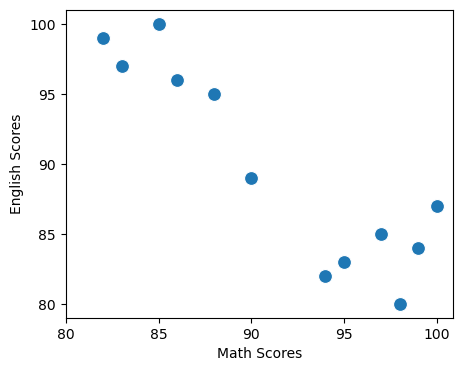

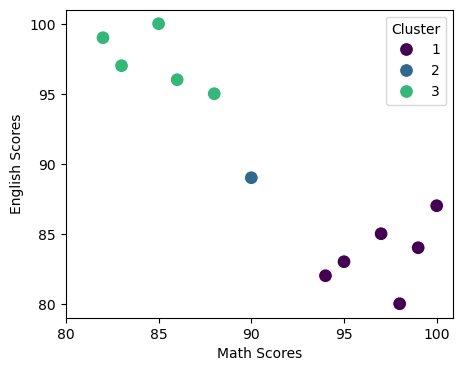

In [8]:
data = pd.DataFrame({
    'Math Scores': [98, 99, 95, 94, 100, 97, 90, 88, 82, 85, 86, 83],
    'English Scores': [80, 84, 83, 82, 87, 85, 89, 95, 99, 100, 96, 97],
    'Cluster': [1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3]
})

plt.figure(figsize = (5, 4))
sns.scatterplot(data, x = 'Math Scores', y = 'English Scores', s = 100)
plt.xticks([80, 85, 90, 95, 100])
plt.yticks([80, 85, 90, 95, 100])
plt.savefig(images + 'math_english_scatter.png', dpi = 300, bbox_inches = 'tight')
plt.show()

cmap = plt.get_cmap('viridis', 4)

plt.figure(figsize = (5, 4))
sns.scatterplot(data, x = 'Math Scores', y = 'English Scores', hue = 'Cluster', palette = {i + 1: cmap(i) for i in range(3)}, s = 100)
plt.xticks([80, 85, 90, 95, 100])
plt.yticks([80, 85, 90, 95, 100])
plt.savefig(images + 'math_english_scatter_colored.png', dpi = 300, bbox_inches = 'tight')
plt.show()

#### All parcels

In [ ]:
toPlot = parcels.drop_duplicates(subset = 'parcelID').copy()

fig = px.scatter_mapbox(toPlot, lat = 'lat', lon = 'lng', zoom = 10)
fig.update_layout(mapbox_style = 'carto-positron')
fig.write_image(images + 'parcel_centers.png')
fig.show()

#### Pittsburgh boundary

In [7]:
geojson = gpd.read_file(raw + 'Pittsburgh_Boundary.geojson')

boundary = geojson.geometry.iloc[2]
# this is the perimeter of the city

polygons = [geom for geom in boundary.geoms]

In [50]:
city = geojson.dissolve()
mpoly = city.geometry.iloc[0]

lngs = []
lats = []

for poly in mpoly.geoms:
    for x, y in poly.exterior.coords:
        lngs.append(x)
        lats.append(y)

bounds = pd.DataFrame({
    'lat': lats,
    'lng': lngs
})

In [5]:
# toPlot = bounds

# fig = px.scatter_mapbox(bounds, lat = 'lat', lon = 'lng', zoom = 10)
# fig.update_layout(mapbox_style = 'carto-positron')
# # fig.write_image(images + 'pittsburgh_boundary.png')
# fig.show()

In [53]:
def construct_perimeter(parcels, r):
    x_vals = [i for i in range(0, r + 1, 1)]
    y_vals = []

    for x in x_vals:
        y = np.sqrt( (r ** 2) - (x ** 2) )
        y_vals.append(y)
        pass
    
    conversionVector = np.array([85500, 111111.111])
    coords1 = np.array([[i, j] for i, j in zip(x_vals, y_vals)]) / conversionVector
    coords2 = coords1 * np.array([-1, 1])
    coords3 = coords1 * np.array([-1, -1])
    coords4 = coords1 * np.array([1, -1])
    
    polyX_vals = []

    for index, row in parcels.iterrows():
        origin = np.array([row['lng'], row['lat']])
        coordsX_1 = origin + coords1
        coordsX_2 = origin + coords2
        coordsX_3 = origin + coords3
        coordsX_4 = origin + coords4
        coordsX = np.concatenate((coordsX_1, coordsX_2, coordsX_3, coordsX_4))
        polyX = Polygon(coordsX)
        polyX_vals.append(polyX)
        pass
    
    return polyX_vals

In [4]:
# np.random.seed(1)
# parcel = parcels.loc[parcels['blight'] == 1].sample(5)
# parcel['radius_750'] = construct_perimeter(parcel, 750)
# perimeter_coords = (
#     pd.DataFrame([parcel['radius_750'].values[i].exterior.xy for i in range(parcel.shape[0])]).rename(columns = {0: 'lng', 1: 'lat'})
#     .apply(pd.Series.explode).reset_index(drop = True)
#     .assign(type = 'parcel')
# )
# toPlot = pd.concat([
#     parcel[['lat', 'lng']].assign(type = 'parcel'), perimeter_coords.assign(type = 'parcel'), bounds.assign(type = 'boundary')
# ], axis = 0)

# cmap = {
#     'parcel': 'rgba(68,1,84,0.8)',
#     'boundary': '#4169E1'
# }

# fig = px.scatter_mapbox(toPlot, lat = 'lat', lon = 'lng', color = 'type', color_discrete_map = cmap, zoom = 10)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.write_image(images + 'pittsburgh_boundary_and_parcels.png')
# fig.show()

#### Circle segment formula (minor)

# Non-Observable Area Multiplier: Derivation

---

## Step 1: Haversine Distance

Given two points $(\varphi_1, \lambda_1)$ and $(\varphi_2, \lambda_2)$ (latitude and longitude in radians), the Haversine distance is:

$$a = \sin^2\!\left(\frac{\varphi_2 - \varphi_1}{2}\right) + \cos(\varphi_1)\cos(\varphi_2)\sin^2\!\left(\frac{\lambda_2 - \lambda_1}{2}\right)$$

$$d_H = 2R_\oplus \arcsin\!\left(\sqrt{a}\right)$$

where $R_\oplus = 6{,}378{,}137$ m is the Earth's radius.

---

## Step 2: Proportion of Circle Inside the City

For each parcel $i$, a circle of radius $R = 750$ m is drawn around it. A grid of points uniformly covering the circle is generated, and the proportion lying within the city boundary $\mathcal{C}$ is computed:

$$p_i = \frac{\#\{\text{grid points} \in \mathcal{C}\}}{\#\{\text{grid points in circle}\}}$$

The observable and unobservable (outside-city) areas are then:

$$A_{\text{in},i} = \pi R^2 \cdot p_i, \qquad A_{\text{out},i} = \pi R^2 (1 - p_i)$$

---

## Step 3: Implied Distance to a Flat Boundary

The true city boundary is irregular, so we model the unobservable area as the *minor circular segment* cut off by a single chord at perpendicular distance $d$ from the parcel. For a circle of radius $R$, the area of such a segment is:

$$A_{\text{seg}}(d, R) = R^2 \arccos\!\left(\frac{d}{R}\right) - d\sqrt{R^2 - d^2}$$

We solve for the *implied distance* $d_i$ such that the segment area equals the computed outside area:

$$R^2 \arccos\!\left(\frac{d_i}{R}\right) - d_i\sqrt{R^2 - d_i^2} = A_{\text{out},i}$$

This is solved numerically (Newton's method via `mpmath.findroot`) with initial guess $d_0 = R/2$.

**Sign convention:**
- $d_i > 0$: parcel centre is inside the city; the boundary is at distance $d_i$
- $d_i < 0$: parcel centre lies outside the city

---

## Step 4: Annulus-Specific Adjustment Factors

For a sequence of annular rings with inner radius $R - 50$ and outer radius $R$ (for $R \in \{50, 100, \ldots, 750\}$ m), we compute the fraction of each annulus that lies inside the city.

### Case A: $d_i > 0$ (parcel centre inside city)

**Sub-case A1:** $d_i \geq R$ — the boundary does not intersect the circle at radius $R$:

$$\alpha_R = 1$$

**Sub-case A2:** $d_i < R$ — the boundary cuts the circle. The area of the full circle of radius $R$ inside the city is:

$$A_{\text{in}}(R) = \pi R^2 - R^2\arccos\!\left(\frac{d_i}{R}\right) + d_i\sqrt{R^2 - d_i^2}$$

The area of the annulus $[R-50,\; R]$ inside the city is:

$$A_{\text{annulus, in}}(R) = \begin{cases} A_{\text{in}}(R) - \pi(R-50)^2 & \text{if } R - d_i < 50 \\ A_{\text{in}}(R) - A_{\text{in}}(R - 50) & \text{otherwise} \end{cases}$$

The full annulus area is $A_{\text{annulus}} = \pi R^2 - \pi(R-50)^2$, giving adjustment:

$$\alpha_R = \max\!\left(\alpha_{\min},\; \frac{A_{\text{annulus, in}}(R)}{A_{\text{annulus}}}\right)$$

### Case B: $d_i \leq 0$ (parcel centre outside city)

Let $\delta = |d_i|$. The inside area is computed as before, but the inside/outside fractions are *flipped*:

$$\text{annuli\_percent\_in} = \frac{A_{\text{annulus, in}}(R)}{A_{\text{annulus}}}$$

$$\alpha_R = \max\!\left(\alpha_{\min},\; 1 - \text{annuli\_percent\_in}\right)$$

If $\delta \geq R$, the boundary does not intersect the circle and the parcel is entirely outside the city:

$$\alpha_R = \alpha_{\min}$$

### Floor on the Adjustment

In all cases a minimum threshold $\alpha_{\min} = 0.25$ is imposed, capping the maximum adjustment multiplier at $4\times$:

$$\alpha_R \geq \alpha_{\min} = 0.25$$

---

## Step 5: Applying the Adjustment

For parcel $i$ at annular band $R$, the adjusted count of neighbouring blighted parcels is:

$$\tilde{n}_{i,R} = \frac{n_{i,R}}{\alpha_R}$$

where $n_{i,R}$ is the raw observed count within the annulus $[R-50,\; R]$ and $\alpha_R \in [\alpha_{\min},\; 1]$ is the fraction of that annulus observable within the city boundary.

$$A = \frac{r^2}{2}(\theta - \sin\theta)$$

#### parcels/viols/crimes raw and clean heads

In [89]:
raw_parcels = pd.read_csv(raw + 'raw_parcels.csv')
raw_parcels.head(1)

,_id,OBJECTID_12,OBJECTID_1,OBJECTID,PIN,MAPBLOCKLO,MUNICODE,CALCACREAG,NOTES,PSEUDONO,COMMENTS,GlobalID,Shape_Leng,Latitude,Longitude,FID_1,OBJECTID_2,OBJECTID_3,OBJECTID_4,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,UR10,UACE10,UATYP10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geoid2,geo_name_c,geo_id_cou,level_coun,geo_name_n,geo_id_nho,level_nhoo,geo_name_t,geo_id_tra,level_trac,geo_name_b,geo_id_blo,level_bloc,geo_name_1,geo_id_c_1,level_cous,geo_name_z,geo_id_zip,level_zipc,geo_name_s,geo_id_sch,level_scho,geo_name_H,geo_id_Hou,level_Hous,geo_name_2,geo_id_Sen,level_Sena,geo_name_3,geo_id_c_2,level_co_1,OBJECTID_5,Pgh_PLI_Zo,Pgh_CityCo,Pgh_Police,Pgh_FireDi,Pgh_DPW_Di,Pgh_Ward,Distance,Shape_Le_1,Shape_Le_2,Shape_Ar_1,LatitudeStatePlane,LongitudeStatePlane
0,1,1,203,203,0627N00091000000,627-N-91,815,0.29,,,,{18151AA4-DE80-4E58-87C6-8ED7019CD783},449.15,40.54,-79.80,23,24,24,270,42,3,418000,1030,420034180001030,Block 1030,G5040,U,69697,U,S,"13,792.00",0.00,40.54,-79.80,"420,034,180,001,000.00",Allegheny,42003,County,,,,418000,42003418000,Census Tract,Tract 418000 Block Group 1,420034180001,Block Group,Cheswick borough,13392,County Subarea,15024,15024,Zip Code,Allegheny Valley SD,103020603,School District,PA House District 33,PAHOUSE33,PA House,PA Senate District 38,PASEN38,PA Senate,District 7,CC7,County Council,1444,0,0,0,,0,0,0.00,0.00,655.35,"23,906.34","446,260.89","1,399,413.76"


In [92]:
parcels.iloc[:, :5].head(1)

,parcelID,lat,lng,nbrhd,tract
0,0001A00100000000,40.44,-80.01,Central Business District,20100


In [94]:
raw_viols = pd.read_csv(raw + 'raw_viols.csv')
raw_viols.head(1)

,_id,casefile_number,address,parcel_id,status,investigation_date,violation_description,violation_code_section,violation_spec_instructions,investigation_outcome,investigation_findings
0,1,CF-PLI-2025-023716,"609 JUNILLA ST, PITTSBURGH, PA 15219-",0010G00039000000,IN VIOLATION,2025-06-05,NO ADDRESS IDENTIFICATION ON BUILDING.,2015 IPMC 304.3,CORRECT AND OR REPLACE BUILDING IDENTIFICATION...,VIOLATION FOUND,NO IDENTIFICATION ON BUILDING HAS BEEN CITED.


In [95]:
viols = pd.read_csv(clean + 'clean_viols.csv')
viols.head(1)

,violID,parcelID,date,code,outcome,lat,lng
0,CF-PLI-2025-023716,0010G00039000000,2025-06-05,2015 IPMC 304.3,VIOLATION FOUND,40.45,-79.97


In [98]:
raw_crimes = pd.read_csv(raw + 'raw_crimes_old.csv')
raw_crimes.head(1)

,_id,PK,CCR,HIERARCHY,INCIDENTTIME,INCIDENTLOCATION,CLEAREDFLAG,INCIDENTNEIGHBORHOOD,INCIDENTZONE,INCIDENTHIERARCHYDESC,OFFENSES,INCIDENTTRACT,COUNCIL_DISTRICT,PUBLIC_WORKS_DIVISION,X,Y
0,1,2802309,"16,000,001.00",10,2016-01-01T00:00:00,"400 Block North Shore DR Pittsburgh, PA 15212",Y,North Shore,1,HARRASSMENT/THREAT/ATTEMPT/PHY,2702 Aggravated Assault. / 2709(a) Harassment....,"2,205.00",1.00,6.00,-80.01,40.45


In [96]:
crimes = pd.read_csv(clean + 'clean_crimes.csv')
crimes.head(1)

,crime,severity,date,address,nbrhd,zone,tract,lat,lng
0,9492 Dog Bite,Low,2020-01-01T00:18:00,"600 Block Elmbank ST Pittsburgh, PA 15226",Brookline,6,"1,917.00",40.40,-80.02


In [74]:
parcels[['parcelID', 'lat', 'lng', 'nbrhd', 'tract', 'viols_sqrt', 'low_sqrt', 'high_sqrt']]

,parcelID,lat,lng,nbrhd,tract,viols_sqrt,low_sqrt,high_sqrt
0,0001A00100000000,40.44,-80.01,Central Business District,20100,5.07,7.90,6.80
1,0001B00010000000,40.44,-80.01,Central Business District,20100,8.10,12.13,9.93
2,0001B00024000000,40.44,-80.01,Central Business District,20100,6.17,9.29,7.59
3,0001B00026000000,40.44,-80.01,Central Business District,20100,6.34,9.54,7.72
4,0001B00050000000,40.44,-80.01,Central Business District,20100,6.85,10.27,8.46
...,...,...,...,...,...,...,...,...
144026,8000T04522000000,40.40,-80.00,Brookline,320600,12.93,6.87,4.69
144027,8000T04662000000,40.39,-80.00,Brookline,320600,12.83,6.79,4.64
144028,8000T04810000000,40.41,-80.03,Banksville,202300,8.27,4.05,3.03
144029,8000T04973000000,40.45,-80.07,Windgap,563000,16.92,5.49,4.63


In [ ]:
parcels[['viols_sqrt', 'low_sqrt', 'high_sqrt', 'pc_blight']]

,viols_sqrt,low_sqrt,high_sqrt,pc_blight
0,5.07,7.90,6.80,-0.24
1,8.10,12.13,9.93,-0.03
2,6.17,9.29,7.59,-0.17
3,6.34,9.54,7.72,-0.16
4,6.85,10.27,8.46,-0.12
...,...,...,...,...
144026,12.93,6.87,4.69,-0.19
144027,12.83,6.79,4.64,-0.19
144028,8.27,4.05,3.03,-0.36
144029,16.92,5.49,4.63,-0.15


In [76]:
parcels[['viols_sqrt', 'low_sqrt', 'high_sqrt', 'blight']]

,viols_sqrt,low_sqrt,high_sqrt,blight
0,5.07,7.90,6.80,2
1,8.10,12.13,9.93,4
2,6.17,9.29,7.59,4
3,6.34,9.54,7.72,4
4,6.85,10.27,8.46,4
...,...,...,...,...
144026,12.93,6.87,4.69,2
144027,12.83,6.79,4.64,2
144028,8.27,4.05,3.03,1
144029,16.92,5.49,4.63,2


#### All of Pittsburgh, Oakland highlighted

In [3]:
# oakland = ['South Oakland', 'North Oakland', 'West Oakland', 'Central Oakland']

# toPlot = parcels.assign(type = np.where(parcels['nbrhd'].isin(oakland), 'Oakland', 'Pittsburgh'))[['lat', 'lng', 'type']]

# cmap = {
#     'Oakland': '#E69F00',
#     'Pittsburgh': 'rgba(68,1,84,0.8)'
# }

# fig = px.scatter_mapbox(toPlot, lat = 'lat', lon = 'lng', color = 'type', color_discrete_map = cmap, zoom = 10)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.write_image(images + 'pittsburgh_oakland_highlighted.png')
# fig.show()

In [2]:
# oakland = parcels.loc[parcels['nbrhd'].str.contains('Oakland')]

# cmap = [
#         '#440154',
#         '#443983',
#         '#31688e',
#         '#21918c',
#         '#35b779',
#         '#90d743',
#         #'#fde725'
# ]

# fig = px.scatter_mapbox(oakland, lat = 'lat', lon = 'lng', color = 'blight', color_continuous_scale = cmap, zoom = 11)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.write_image(images + 'oakland_blight_categorical.png')
# fig.show()

In [1]:
# rescaled = pd.DataFrame(MinMaxScaler().fit_transform(pd.DataFrame(parcels['pc_blight'])), columns = ['pc_blight']).assign(
#     lat = parcels['lat'],
#     lng = parcels['lng'],
#     nbrhd = parcels['nbrhd']
# )

# oakland = rescaled.loc[rescaled['nbrhd'].str.contains('Oakland')]

# fig = px.scatter_mapbox(oakland, lat = 'lat', lon = 'lng', color = 'pc_blight', color_continuous_scale = 'viridis', range_color = [0, 1], zoom = 11)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.write_image(images + 'oakland_blight_pc.png')
# fig.show()

In [12]:
# oakland = parcels.loc[parcels['nbrhd'].str.contains('Oakland')]

# fig = px.scatter_mapbox(oakland, lat = 'lat', lon = 'lng', color = 'nbrhd', color_continuous_scale = cmap, zoom = 11)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.show()

#### Maps of BPU and parcel-wise viol scores (continuous)

In [11]:
bpu = pd.read_csv(clean + 'BPU_blight.csv')
bpu = parcels.merge(bpu, on = 'tract', how = 'left')

In [14]:
# fig = px.scatter_mapbox(bpu, lat = 'lat', lon = 'lng', color = 'm1_viols_sqrt', color_continuous_scale = 'viridis', zoom = 10)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.write_image(images + 'bpu_viols_map.png')
# fig.show()

In [15]:
# fig = px.scatter_mapbox(parcels, lat = 'lat', lon = 'lng', color = 'viols_sqrt', color_continuous_scale = 'viridis', zoom = 10)
# fig.update_layout(mapbox_style = 'carto-positron')
# fig.write_image(images + 'parcels_viols_map.png')
# fig.show()

#### Population proportions of each blight category

In [6]:
demos = pd.read_csv(clean + 'blight_and_demos.csv')

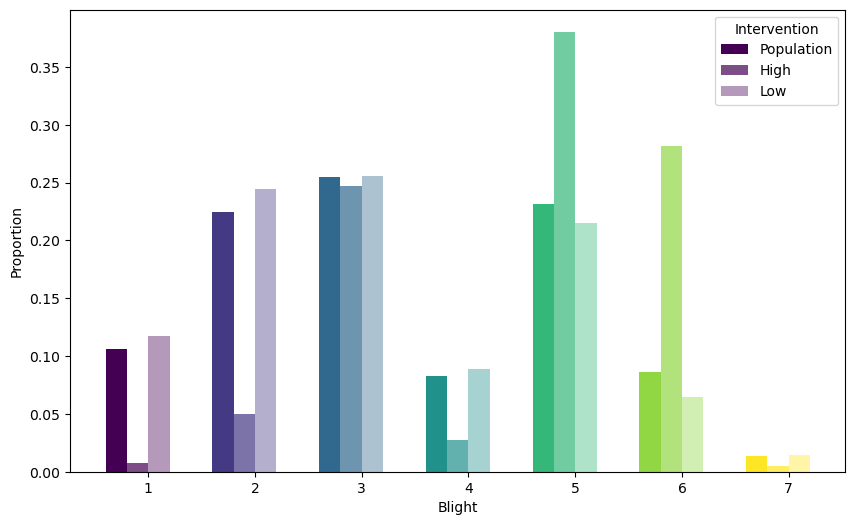

In [25]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.concat([
    parcels['blight'].value_counts(normalize=True).reset_index().assign(exposure='Population'),
    demos.groupby('exposure')['blight_sqrt'].value_counts(normalize=True).reset_index().rename(columns={'blight_sqrt': 'blight'})
], axis=0)

blight_cats = list(range(1, 8))
exposures = ['Population', 'High', 'Low']

n_cats = len(blight_cats)
n_exp = len(exposures)

base_colors = [cm.viridis(i / (n_cats - 1)) for i in range(n_cats)]
alphas = np.linspace(1.0, 0.4, n_exp)  # Population=1.0, High=0.7, Low=0.4

bar_width = 0.2
x = np.arange(n_cats)

fig, ax = plt.subplots(figsize=(10, 6))

for j, exp in enumerate(exposures):
    subset = df[df['exposure'] == exp].set_index('blight').reindex(blight_cats)
    for i, (cat, base) in enumerate(zip(blight_cats, base_colors)):
        r, g, b, _ = base
        color = (r, g, b, alphas[j])
        ax.bar(
            x[i] + j * bar_width - (n_exp * bar_width / 2),
            subset.loc[cat, 'proportion'],
            width=bar_width,
            color=color,
            label=exp if i == 0 else None
        )

ax.set_xticks(x)
ax.set_xticklabels(blight_cats)
ax.set_xlabel('Blight')
ax.set_ylabel('Proportion')
ax.legend(title='Intervention')
plt.savefig(images + 'proportions_blight_by_demo_exposure.png', dpi = 300, bbox_inches = 'tight')
plt.show()

#### Category 6, low/high demo exposure

In [6]:
demos = pd.read_csv(clean + 'static_blight_and_demos.csv')

In [21]:
toPlot = demos.query('blight == 6').assign(blight = lambda x: x['blight'].astype(str))

cmap = {
    '6': '#90d743'
}

fig = px.scatter_mapbox(toPlot, lat = 'lat', lon = 'lng', color = 'blight', color_discrete_map = cmap, zoom = 10)
fig.update_layout(mapbox_style = 'carto-positron')
fig.write_image(images + 'just_category_6.png')
fig.show()

In [22]:
toPlot = demos.query('blight == 6')

cmap = {
    'High': '#9B8EC4',
    'Low': '#90d743'
}

fig = px.scatter_mapbox(toPlot, lat = 'lat', lon = 'lng', color = 'exposure', color_discrete_map = cmap, zoom = 10)
fig.update_layout(mapbox_style = 'carto-positron')
fig.write_image(images + 'category_6_demo_exposure.png')
fig.show()